# Project Hilbert-Link — Data Preparation (QM9)
Runs once. Saves processed data to `BASE_DIR` for `model.py` to consume.

## Dataset: QM9
~134k small organic molecules (C, H, O, N, F) com até 9 átomos pesados.
Ideal para modelos generativos de grafos moleculares (MolGAN, JTVAE, etc.).

## Filtros aplicados
1. **Validade RDKit** — descarta SMILES não parseáveis
2. **Sanitização** — descarta moléculas que falham na sanitização química
3. **Átomos pesados ≤ NUM_ATOMS** — alinha com o featurizador MolGAN
4. **Tipos de átomos permitidos** — apenas {C, N, O, F} (padrão QM9 sem H explícito)
5. **Molécula conectada** — descarta fragmentos (sem '.' no SMILES)
6. **Peso molecular ≤ 200 Da** — foca moléculas geráveis / drug-like pequenas
7. **Remoção de duplicatas** — canonical SMILES único
8. **GraphMatrix válido** — descarta featurizações malsucedidas

In [1]:
import sys
print(f'Versão do Python: {sys.version}')
print(f'Caminho do Executável: {sys.executable}')

Versão do Python: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
Caminho do Executável: /scratch/lustre/home/glmo2483/miniconda/envs/hilbert-link/bin/python


In [2]:
import config

In [3]:
# Data Directory
BASE_DIR = 'data'

import os
os.makedirs(BASE_DIR, exist_ok=True)
print(f'BASE_DIR: {BASE_DIR}')

BASE_DIR: data


In [4]:
!{sys.executable} -m pip install --pre deepchem --quiet
!{sys.executable} -m pip install rdkit fcd_torch pennylane --quiet
!{sys.executable} -m pip install tensorflow --quiet
!{sys.executable} -m pip install tqdm torch matplotlib --quiet

In [5]:
import warnings
from rdkit import RDLogger

# Silencia avisos do Python (DeepChem/Pandas)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Silencia os logs do RDKit
logger = RDLogger.logger()
logger.setLevel(RDLogger.CRITICAL)

import logging

# Silencia os logs do DeepChem
logger = logging.getLogger('deepchem')
logger.setLevel(logging.ERROR)

In [6]:
# ====================== SEEDS ======================
import random, numpy as np, torch
SEED = config.SEED
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print('Seeds synchronized.')

Seeds synchronized.


In [7]:
# ====================== Imports ======================
import pickle, pandas as pd
import deepchem as dc
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from deepchem.feat.molecule_featurizers.molgan_featurizer import GraphMatrix

I0000 00:00:1778740563.892211 3975373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778740567.904092 3975373 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778740657.223549 3975373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778740657.259734 3975373 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


In [8]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), 'data'))
import config
from config import *

In [9]:
# ====================== LOAD RAW DATA — QM9 ======================
# QM9: ~134k moléculas orgânicas pequenas (CNOF) com propriedades DFT
# split='random' garante reproducibilidade com a seed acima
print('Baixando/carregando QM9 (pode demorar na primeira vez)...')
tasks, datasets, transformers = dc.molnet.load_qm9(splitter='random')

# Junta train + valid + test para ter o máximo de moléculas disponíveis
# (em preparação de dados para generative models não há data-leakage de split)
all_smiles = list(datasets[0].ids) + list(datasets[1].ids) + list(datasets[2].ids)
df = pd.DataFrame({'smiles': all_smiles})
print(f'Total bruto carregado: {len(df)} moléculas')

Baixando/carregando QM9 (pode demorar na primeira vez)...


/scratch/lustre/home/glmo2483/miniconda/envs/hilbert-link/lib/python3.12/site-packages/deepchem/feat/molecule_featurizers/coulomb_matrices.py:151: RuntimeWarning: divide by zero encountered in divide
  m = np.outer(z, z) / d
/scratch/lustre/home/glmo2483/miniconda/envs/hilbert-link/lib/python3.12/site-packages/deepchem/feat/molecule_featurizers/coulomb_matrices.py:151: RuntimeWarning: divide by zero encountered in divide
  m = np.outer(z, z) / d
/scratch/lustre/home/glmo2483/miniconda/envs/hilbert-link/lib/python3.12/site-packages/deepchem/feat/molecule_featurizers/coulomb_matrices.py:151: RuntimeWarning: divide by zero encountered in divide
  m = np.outer(z, z) / d
/scratch/lustre/home/glmo2483/miniconda/envs/hilbert-link/lib/python3.12/site-packages/deepchem/feat/molecule_featurizers/coulomb_matrices.py:151: RuntimeWarning: divide by zero encountered in divide
  m = np.outer(z, z) / d
/scratch/lustre/home/glmo2483/miniconda/envs/hilbert-link/lib/python3.12/site-packages/deepchem/feat

Total bruto carregado: 130557 moléculas


In [10]:
# ====================== FILTROS PARA MODELOS GENERATIVOS ======================

# Átomos permitidos no QM9 (sem H explícito — MolGAN usa H implícito)
ALLOWED_ATOMS = {'C', 'N', 'O', 'F'}
MAX_MW        = 200.0   # Da — moléculas pequenas são mais fáceis de gerar
MAX_ATOMS     = config.NUM_ATOMS  # alinhado com o featurizador

def passes_filters(smi: str) -> bool:
    """
    Retorna True se a molécula passa em todos os critérios de qualidade
    para treinamento de modelos generativos.
    """
    # --- Filtro 1: Validade RDKit ---
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return False

    # --- Filtro 2: Sanitização química ---
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return False

    # --- Filtro 3: Molécula conectada (sem fragmentos) ---
    if '.' in smi:
        return False

    # --- Filtro 4: Contagem de átomos pesados ≤ MAX_ATOMS ---
    if mol.GetNumAtoms() >= MAX_ATOMS:
        return False

    # --- Filtro 5: Apenas tipos de átomos permitidos (C, N, O, F) ---
    atom_symbols = {atom.GetSymbol() for atom in mol.GetAtoms()}
    if not atom_symbols.issubset(ALLOWED_ATOMS):
        return False

    # --- Filtro 6: Peso molecular ≤ MAX_MW ---
    if Descriptors.MolWt(mol) > MAX_MW:
        return False

    return True


print('Aplicando filtros...')
n0 = len(df)

# --- Filtro 7: Remoção de duplicatas via canonical SMILES ---
df['canon_smiles'] = df['smiles'].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s))
    if Chem.MolFromSmiles(s) else None
)
df.dropna(subset=['canon_smiles'], inplace=True)
df.drop_duplicates(subset=['canon_smiles'], inplace=True)
n1 = len(df)
print(f'  Após deduplicação (canonical SMILES): {n1:,} (-{n0 - n1:,})')

# Aplica todos os demais filtros
mask = df['canon_smiles'].apply(passes_filters)
df_filtered = df[mask].copy()
n2 = len(df_filtered)
print(f'  Após filtros de qualidade:            {n2:,} (-{n1 - n2:,})')

filtered_smiles = df_filtered['canon_smiles'].tolist()
print(f'\nTotal após todos os filtros: {len(filtered_smiles):,} moléculas')

Aplicando filtros...
  Após deduplicação (canonical SMILES): 130,395 (-162)
  Após filtros de qualidade:            121,633 (-8,762)

Total após todos os filtros: 121,633 moléculas


In [11]:
# ====================== FEATURIZE ======================
feat = dc.feat.MolGanFeaturizer(
    max_atom_count=MAX_ATOMS,
    atom_labels=config.ATOM_LABELS
)

features = feat.featurize(filtered_smiles)

# --- Filtro 8: GraphMatrix válido ---
indices      = [i for i, d in enumerate(features) if type(d) is GraphMatrix]
features     = [features[i] for i in indices]
train_smiles = [filtered_smiles[i] for i in indices]

print(f'Featurizações válidas (GraphMatrix): {len(features):,}')
print(f'train set final:                     {len(train_smiles):,}')

Featurizações válidas (GraphMatrix): 121,630
train set final:                     121,630


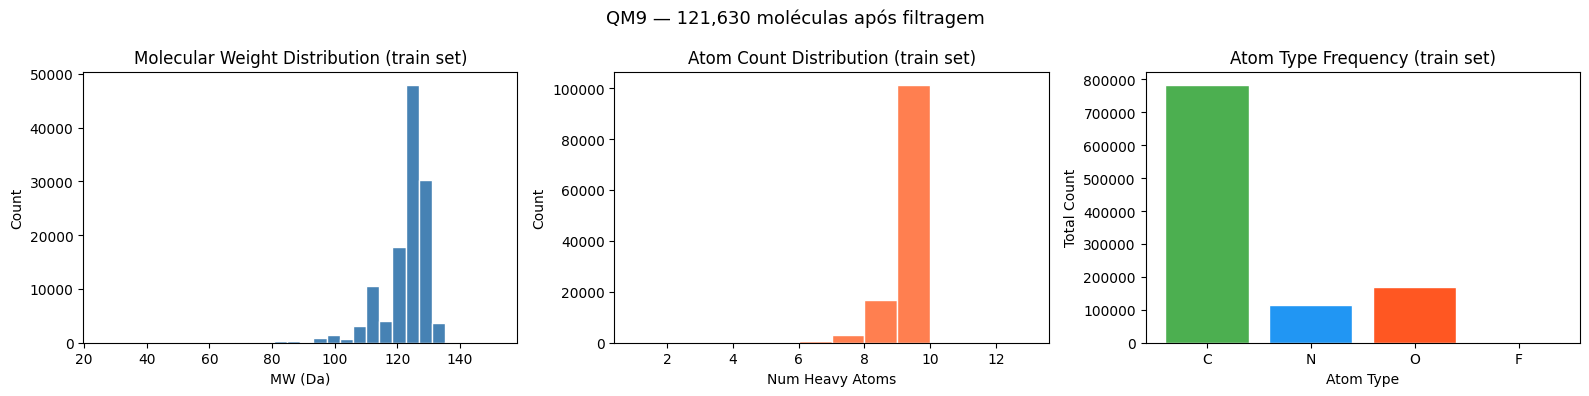

Plot saved.


In [12]:
# ====================== QUICK EXPLORATION ======================
import matplotlib.pyplot as plt

mols        = [Chem.MolFromSmiles(s) for s in train_smiles]
mws         = [Descriptors.MolWt(m)  for m in mols if m]
atom_counts = [m.GetNumAtoms()        for m in mols if m]

# Contagem de átomos por tipo
from collections import Counter
atom_type_counter = Counter(
    atom.GetSymbol()
    for m in mols if m
    for atom in m.GetAtoms()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(mws, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Molecular Weight Distribution (train set)')
axes[0].set_xlabel('MW (Da)')
axes[0].set_ylabel('Count')

axes[1].hist(atom_counts, bins=range(1, MAX_ATOMS + 2), color='coral', edgecolor='white')
axes[1].set_title('Atom Count Distribution (train set)')
axes[1].set_xlabel('Num Heavy Atoms')
axes[1].set_ylabel('Count')

labels  = list(atom_type_counter.keys())
values  = list(atom_type_counter.values())
colors  = ['#4CAF50', '#2196F3', '#FF5722', '#9C27B0']
axes[2].bar(labels, values, color=colors[:len(labels)], edgecolor='white')
axes[2].set_title('Atom Type Frequency (train set)')
axes[2].set_xlabel('Atom Type')
axes[2].set_ylabel('Total Count')

plt.suptitle(f'QM9 — {len(train_smiles):,} moléculas após filtragem', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data_exploration.png'), dpi=150)
plt.show()
print('Plot saved.')

In [13]:
# ====================== RESUMO DOS FILTROS ======================
print('=' * 50)
print('RESUMO DO PIPELINE DE FILTRAGEM (QM9)')
print('=' * 50)
print(f'  Moléculas brutas carregadas : {n0:>8,}')
print(f'  Após deduplicação           : {n1:>8,}')
print(f'  Após filtros de qualidade   : {n2:>8,}')
print(f'  Após featurização (final)   : {len(train_smiles):>8,}')
print('=' * 50)
print(f'  MAX_ATOMS     : {MAX_ATOMS}')
print(f'  MAX_MW        : {MAX_MW} Da')
print(f'  ALLOWED_ATOMS : {sorted(ALLOWED_ATOMS)}')
print('=' * 50)

RESUMO DO PIPELINE DE FILTRAGEM (QM9)
  Moléculas brutas carregadas :  130,557
  Após deduplicação           :  130,395
  Após filtros de qualidade   :  121,633
  Após featurização (final)   :  121,630
  MAX_ATOMS     : 12
  MAX_MW        : 200.0 Da
  ALLOWED_ATOMS : ['C', 'F', 'N', 'O']


In [14]:
#train_smiles = pd.Series(train_smiles).sample(frac=0.1, random_state=42).tolist()

In [15]:
len(train_smiles)

121630

In [16]:
# ====================== SAVE TO DISK ======================
import numpy as np

data_payload = {
    'train_smiles':  train_smiles,
    'adj_matrices': [x.adjacency_matrix.tolist() for x in features],
    'node_features': [x.node_features.tolist()    for x in features],
}



save_path = os.path.join(BASE_DIR, 'prepared_data.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(data_payload, f)

print(f'Saved {len(train_smiles):,} molecules → {save_path}')

Saved 121,630 molecules → data/prepared_data.pkl
